# Gaussian-Only Single Intermediate-Lens Inversion

This notebook demonstrates a minimal inverse experiment for one TEM intermediate lens. The forward data are generated only with the TemGym Gaussian-beam machinery: a known waffle-grating object is represented by Gaussian beamlets, propagated through `ElectromagneticLens`, and evaluated on a detector.

The inverse fit does not use analytic image rendering. It extracts image centroids from Gaussian-rendered intensity images, regresses first-order transfer blocks, and then fits a compact first-order surrogate of the same electromagnetic lens physics.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from io import BytesIO
from pathlib import Path
import sys
import time

import numpy as np
from scipy.optimize import brentq, least_squares
import matplotlib.pyplot as plt
from IPython.display import Image, display

import jax
jax.config.update("jax_enable_x64", True)


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src" / "temgym_core").exists():
            return path
    raise RuntimeError("Could not find repo root containing src/temgym_core")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from temgym_core.components import Detector, ElectromagneticLens, WaffleGrating
from temgym_core.constants import compute_Rc_from_voltage, effective_accelerating_potential
from temgym_core.evaluate import evaluate_gaussians_jax_scan
from temgym_core.gaussian import make_gaussian
from temgym_core.run import run_to_end
from temgym_core.transfer_matrices import lens_matrix_5x5, propagation_matrix_5x5

np.set_printoptions(precision=6, suppress=False)


def show_figure(fig, dpi: int = 140):
    """Embed a Matplotlib figure as PNG output when executed headlessly."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


## Experiment Geometry

The geometry is chosen to form a real intermediate image with modest TEM-like distances. A `20 mm` intermediate lens images an `88 um` periodic waffle grating with target magnification `M = -12`, so the output object is about `1.1 mm` across on the detector ROI.

The conjugate distances are solved with the repo's 5x5 propagation and lens matrices. This calculation is only for experiment design; the rendered images below are propagated through `ElectromagneticLens`.


In [2]:
@dataclass(frozen=True)
class Truth:
    voltage: float = 200e3
    target_magnification: float = -12.0
    f0: float = 0.020
    psi0: float = 0.080
    D0: float = 0.004
    delta: float = 0.010
    x0: float = 20e-6
    y0: float = -15e-6
    turns: float = 2000.0


truth = Truth()


def design_matrix(d1: float, d2: float, f0: float, D0: float) -> np.ndarray:
    """Isotropic split-lens design matrix using repo transfer helpers."""
    half_lens = lens_matrix_5x5(2.0 * f0, xp=np)
    return (
        propagation_matrix_5x5(d2 - D0, xp=np)
        @ half_lens
        @ propagation_matrix_5x5(D0, xp=np)
        @ half_lens
        @ propagation_matrix_5x5(d1, xp=np)
    )


def conjugate_d2_from_lens_entrance(d1: float, f0: float, D0: float) -> float:
    def residual(d2):
        return design_matrix(d1, d2, f0, D0)[0, 2]

    return brentq(residual, D0 + 1e-6, 1.0)


def d1_for_target_magnification(target_magnification: float, f0: float, D0: float) -> float:
    def residual(d1):
        d2 = conjugate_d2_from_lens_entrance(d1, f0, D0)
        return design_matrix(d1, d2, f0, D0)[0, 0] - target_magnification

    return brentq(residual, f0 + 1e-6, 0.08)


d1_truth = d1_for_target_magnification(truth.target_magnification, truth.f0, truth.D0)
d2_truth = conjugate_d2_from_lens_entrance(d1_truth, truth.f0, truth.D0)
p_truth = np.array([
    d1_truth,
    d2_truth,
    truth.f0,
    truth.psi0,
    truth.D0,
    truth.delta,
    truth.x0,
    truth.y0,
])
M_design = design_matrix(d1_truth, d2_truth, truth.f0, truth.D0)

print(f"target magnification = {truth.target_magnification:.3f}")
print(f"d1 object->lens      = {d1_truth * 1e3:.6f} mm")
print(f"d2 lens->screen      = {d2_truth * 1e3:.6f} mm")
print(f"screen z             = {(d1_truth + d2_truth) * 1e3:.6f} mm")
print(f"isotropic A          = {M_design[0, 0]:.6f}")
print(f"isotropic B          = {M_design[0, 2]:.3e} m/rad")


target magnification = -12.000
d1 object->lens      = 20.701754 mm
d2 lens->screen      = 275.578947 mm
screen z             = 296.280702 mm
isotropic A          = -12.000000
isotropic B          = -2.776e-17 m/rad


## TemGym Forward Model

The forward model is a concrete TemGym component sequence:

`GaussianBeam object -> ElectromagneticLens -> Detector`

The current scale is applied to the physical current passed into `ElectromagneticLens`. Therefore the Gaussian propagation includes the implemented current-dependent focal length, current-dependent Larmor rotation, finite thickness, astigmatic stigmator split, and lens centre offset.


In [3]:
def electromagnetic_fields_from_effective(params, voltage=truth.voltage, turns=truth.turns):
    _, _, f0, psi0, D0, delta, x0, y0 = np.asarray(params, dtype=float)
    Rc = float(compute_Rc_from_voltage(voltage))
    V_star = float(effective_accelerating_potential(voltage))
    NI0 = psi0 / Rc
    phi0 = 1.0 / f0
    Gc_geom = V_star * phi0 / NI0**2
    current0 = NI0 / turns
    Tc = D0 / abs(NI0)
    return {
        "turns": turns,
        "current0": current0,
        "NI0": NI0,
        "Gc_geom": Gc_geom,
        "Tc": Tc,
        "stigmator_strength_x": delta,
        "stigmator_strength_y": -delta,
        "x0": x0,
        "y0": y0,
    }


def make_lens(params, current_scale: float = 1.0) -> ElectromagneticLens:
    d1, *_ = np.asarray(params, dtype=float)
    fields = electromagnetic_fields_from_effective(params)
    return ElectromagneticLens(
        z=float(d1),
        turns=float(fields["turns"]),
        current=float(fields["current0"] * current_scale),
        Gc=float(fields["Gc_geom"]),
        Tc=float(fields["Tc"]),
        x0=float(fields["x0"]),
        y0=float(fields["y0"]),
        stigmator_strength_x=float(fields["stigmator_strength_x"]),
        stigmator_strength_y=float(fields["stigmator_strength_y"]),
    )


def make_detector(params, pixel_size, shape) -> Detector:
    d1, d2, *_ = np.asarray(params, dtype=float)
    return Detector(z=float(d1 + d2), pixel_size=(pixel_size, pixel_size), shape=shape)


def make_temgym_model(params, current_scale: float, detector: Detector):
    return (make_lens(params, current_scale), detector)


baseline_lens = make_lens(p_truth, 1.0)
print("Baseline TemGym lens")
print(f"  focal length = {float(baseline_lens.focal_length(truth.voltage)) * 1e3:.6f} mm")
print(f"  rotation     = {float(baseline_lens.rotation_angle(truth.voltage)):.6f} rad")
print(f"  thickness    = {float(baseline_lens.thickness) * 1e3:.6f} mm")
print(f"  excitation   = {float(baseline_lens.excitation):.6f} ampere-turns")


Baseline TemGym lens
  focal length = 20.000000 mm
  rotation     = 0.080000 rad
  thickness    = 4.000000 mm
  excitation   = 150.900504 ampere-turns


## Fast First-Order Inverse Model

For fitting, the notebook uses a compact first-order surrogate. This is not used to render images. It mirrors the paraxial structure of `ElectromagneticLens`: split stigmator kicks, finite internal propagation, current-dependent magnetic rotation, and detector propagation.

The reason this surrogate remains in the notebook is practical: a SciPy least-squares loop calling many full TemGym/JAX forward passes would be slow for an interactive demonstration. The data being fitted still come only from Gaussian-rendered images.


In [4]:
def rotation_matrix_5x5(angle: float) -> np.ndarray:
    c = np.cos(angle)
    s = np.sin(angle)
    M = np.eye(5)
    M[:2, :2] = np.array([[c, -s], [s, c]])
    M[2:4, 2:4] = np.array([[c, -s], [s, c]])
    return M


def stigmator_matrix_5x5(fx: float, fy: float, x0: float, y0: float) -> np.ndarray:
    M = np.eye(5)
    M[2, 0] = -1.0 / fx
    M[3, 1] = -1.0 / fy
    M[2, 4] = x0 / fx
    M[3, 4] = y0 / fy
    return M


def first_order_surrogate_matrix(params: np.ndarray, current_scale: float) -> np.ndarray:
    d1, d2, f0, psi0, D0, delta, x0, y0 = np.asarray(params, dtype=float)
    f = f0 / current_scale**2
    D = D0 * abs(current_scale)
    psi = psi0 * current_scale
    fx = f / (1.0 + delta)
    fy = f / (1.0 - delta)
    half_stig = stigmator_matrix_5x5(2.0 * fx, 2.0 * fy, x0, y0)

    return (
        propagation_matrix_5x5(d2 - D, xp=np)
        @ rotation_matrix_5x5(psi)
        @ half_stig
        @ propagation_matrix_5x5(D, xp=np)
        @ half_stig
        @ propagation_matrix_5x5(d1, xp=np)
    )


M_baseline = first_order_surrogate_matrix(p_truth, 1.0)
print("Baseline first-order A:")
print(M_baseline[:2, :2])
print("Baseline first-order B [m/rad]:")
print(M_baseline[:2, 2:4])


Baseline first-order A:
[[-12.084369   0.949125]
 [ -0.968817 -11.838736]]
Baseline first-order B [m/rad]:
[[-0.002812 -0.000226]
 [-0.000225  0.002815]]


## Gaussian Object And Detectors

The known object is a finite periodic waffle grating: square transmitting holes on a square pitch, clipped to a larger rectangular support. The hole period, hole width, and support size are controlled by `WaffleGrating`, and Gaussian beamlets are sampled from the transmitting regions.

The detector setup has two scales: a physical `160 mm` green screen for context, and a high-resolution ROI where the Gaussian field is actually evaluated.


In [5]:
WAFFLE_GRATING_KWARGS = dict(
    width=88e-6,
    height=88e-6,
    period=8.0e-6,
    hole_width=4.8e-6,
    hole_height=4.8e-6,
    edge_sharpness=7.0e6,
    t_hole=1.0,
    t_bar=0.02,
    t_outside=0.0,
    z=0.0,
)
OBJECT_SAMPLE_SPACING = 2.4e-6
OBJECT_BEAMLET_WAIST = 1.2e-6


def make_waffle_grating(object_shift=(0.0, 0.0)) -> WaffleGrating:
    shift = np.asarray(object_shift, dtype=float)
    return WaffleGrating(
        **WAFFLE_GRATING_KWARGS,
        x0=float(shift[0]),
        y0=float(shift[1]),
    )


def waffle_grating_points(grating: WaffleGrating, spacing=OBJECT_SAMPLE_SPACING, threshold=0.05):
    xs = np.arange(-0.5 * grating.width, 0.5 * grating.width + 0.5 * spacing, spacing)
    ys = np.arange(-0.5 * grating.height, 0.5 * grating.height + 0.5 * spacing, spacing)
    xx, yy = np.meshgrid(xs, ys, indexing="xy")
    points = np.column_stack([xx.ravel(), yy.ravel()])
    transmission = np.asarray(grating.transmission(points), dtype=float)
    keep = transmission > threshold
    return points[keep], transmission[keep]


BASE_WAFFLE_GRATING = make_waffle_grating()
object_points, object_transmission = waffle_grating_points(BASE_WAFFLE_GRATING)
object_weights = np.ones(len(object_points), dtype=float)

SCREEN_DIAMETER = 0.160
SCREEN_SHAPE = (512, 512)
DETECTOR_SHAPE = (256, 256)
DETECTOR_PIXEL_SIZE = 8.0e-6
INPUT_SHAPE = (192, 192)
INPUT_PIXEL_SIZE = 0.75e-6

OUTPUT_DETECTOR = make_detector(p_truth, DETECTOR_PIXEL_SIZE, DETECTOR_SHAPE)
INPUT_DETECTOR = Detector(z=0.0, pixel_size=(INPUT_PIXEL_SIZE, INPUT_PIXEL_SIZE), shape=INPUT_SHAPE)

print(f"object beamlets       = {len(object_points)}")
print(f"grating support       = {BASE_WAFFLE_GRATING.width * 1e6:.1f} x {BASE_WAFFLE_GRATING.height * 1e6:.1f} um")
print(f"grating period        = {BASE_WAFFLE_GRATING.period * 1e6:.1f} um")
print(f"hole width            = {BASE_WAFFLE_GRATING.hole_width * 1e6:.1f} um")
print(f"sampled transmission  = {object_transmission.min():.3f} .. {object_transmission.max():.3f}")
print(f"screen diameter       = {SCREEN_DIAMETER * 1e3:.1f} mm")
print(f"Gaussian ROI width    = {DETECTOR_PIXEL_SIZE * DETECTOR_SHAPE[0] * 1e3:.3f} mm")


object beamlets       = 676
grating support       = 88.0 x 88.0 um
grating period        = 8.0 um
hole width            = 4.8 um
sampled transmission  = 0.265 .. 1.000
screen diameter       = 160.0 mm
Gaussian ROI width    = 2.048 mm


## Gaussian Image Rendering

These functions are the only image generators in the notebook. Output images always call TemGym's `run_to_end` on the component sequence and evaluate the propagated Gaussian beams at a `Detector`.


In [6]:
def make_waffle_grating_beam(object_shift=(0.0, 0.0), beam_tilt=(0.0, 0.0), voltage=truth.voltage):
    pts = object_points + np.asarray(object_shift, dtype=float)
    return make_gaussian(
        x=pts[:, 0],
        y=pts[:, 1],
        dx=np.full(len(pts), beam_tilt[0]),
        dy=np.full(len(pts), beam_tilt[1]),
        z=np.zeros(len(pts)),
        voltage=np.full(len(pts), voltage),
        amp=object_weights,
        phase=np.zeros(len(pts)),
        waist_x=np.full(len(pts), OBJECT_BEAMLET_WAIST),
        waist_y=np.full(len(pts), OBJECT_BEAMLET_WAIST),
        rcurv_x=np.full(len(pts), np.inf),
        rcurv_y=np.full(len(pts), np.inf),
    )


def normalize_intensity(field_or_intensity):
    arr = np.asarray(field_or_intensity)
    if np.iscomplexobj(arr):
        arr = np.abs(arr) ** 2
    arr = np.asarray(arr, dtype=float)
    return arr / max(float(arr.max()), 1e-30)


def render_input_image(object_shift=(0.0, 0.0), beam_tilt=(0.0, 0.0)):
    beam = make_waffle_grating_beam(object_shift=object_shift, beam_tilt=beam_tilt)
    object_component = make_waffle_grating(object_shift=object_shift)
    out = run_to_end(beam, (object_component,))
    field = evaluate_gaussians_jax_scan(out, INPUT_DETECTOR, batch_size=64)
    return normalize_intensity(field)


def render_output_image(params, current_scale=1.0, object_shift=(0.0, 0.0), beam_tilt=(0.0, 0.0)):
    detector = make_detector(params, DETECTOR_PIXEL_SIZE, DETECTOR_SHAPE)
    beam = make_waffle_grating_beam(object_shift=object_shift, beam_tilt=beam_tilt)
    object_component = make_waffle_grating(object_shift=object_shift)
    model = (object_component, *make_temgym_model(params, current_scale, detector))
    out = run_to_end(beam, model)
    field = evaluate_gaussians_jax_scan(out, detector, batch_size=64)
    return normalize_intensity(field)


## Input And Output Images


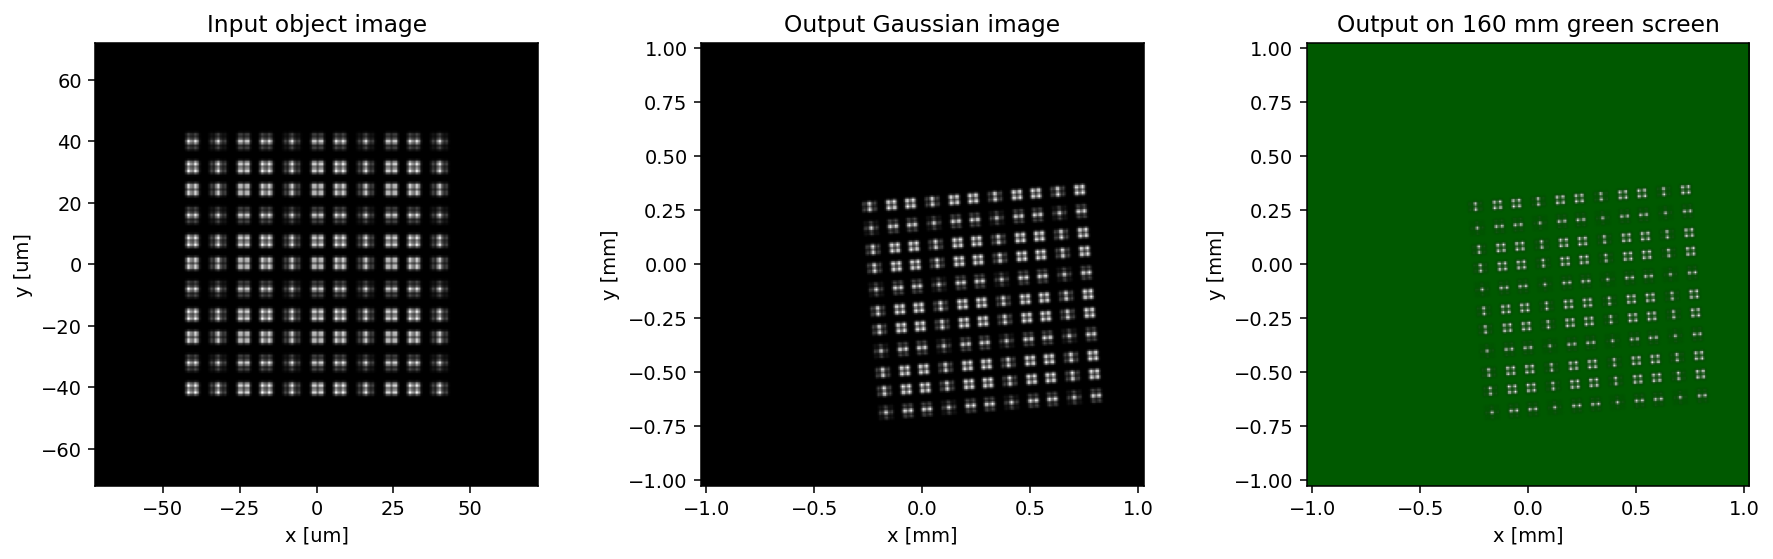

In [7]:
input_image = render_input_image()
output_image = render_output_image(p_truth, current_scale=1.0)

input_extent_um = np.array([-1, 1, -1, 1]) * 0.5 * INPUT_PIXEL_SIZE * INPUT_SHAPE[0] * 1e6
roi_extent_mm = np.array([-1, 1, -1, 1]) * 0.5 * DETECTOR_PIXEL_SIZE * DETECTOR_SHAPE[0] * 1e3
screen_extent_mm = np.array([-1, 1, -1, 1]) * 0.5 * SCREEN_DIAMETER * 1e3

green = np.zeros((*SCREEN_SHAPE, 3), dtype=float)
green[..., 1] = 0.35

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].imshow(input_image, cmap="gray", extent=input_extent_um)
axs[0].set_title("Input object image")
axs[0].set_xlabel("x [um]")
axs[0].set_ylabel("y [um]")

axs[1].imshow(output_image, cmap="gray", extent=roi_extent_mm)
axs[1].set_title("Output Gaussian image")
axs[1].set_xlabel("x [mm]")
axs[1].set_ylabel("y [mm]")

axs[2].imshow(green, extent=screen_extent_mm, origin="lower")
axs[2].imshow(output_image, cmap="gray", extent=roi_extent_mm, alpha=np.clip(output_image, 0.0, 1.0))
axs[2].set_title("Output on 160 mm green screen")
axs[2].set_xlabel("x [mm]")
axs[2].set_ylabel("y [mm]")

for ax in axs:
    ax.set_aspect("equal")
plt.tight_layout()
show_figure(fig)


## Extract Measurements From Gaussian Images

For each current setting, we render images under known object shifts and beam tilts. The measurement extracted from each image is the intensity centroid. Linear regression of centroid against known controls gives measured transfer blocks:

`centroid = A @ object_shift + B @ beam_tilt + offset`


rendered current scale 0.96
rendered current scale 1.00
rendered current scale 1.04
rendered 27 Gaussian output images in 107.0 s


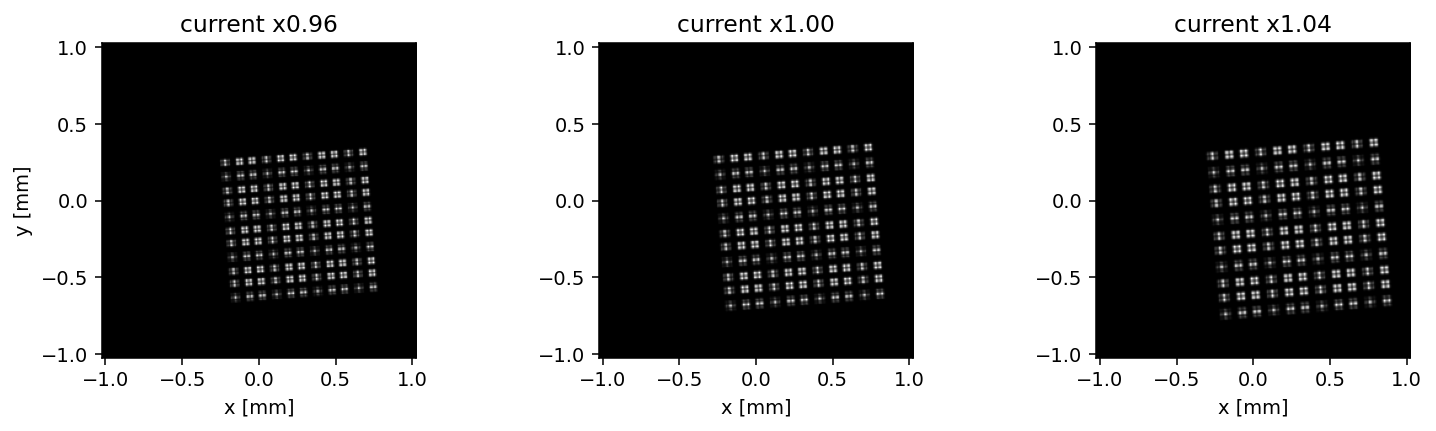

In [8]:
def image_centroid(image: np.ndarray, detector: Detector = OUTPUT_DETECTOR) -> np.ndarray:
    image = np.asarray(image, dtype=float)
    coords = np.asarray(detector.coords).reshape(image.shape[0], image.shape[1], 2)
    x = coords[..., 0]
    y = coords[..., 1]
    weights = np.clip(image, 0.0, None)
    total = weights.sum()
    if total <= 0.0:
        raise ValueError("Cannot compute centroid of an empty image.")
    return np.array([(weights * x).sum() / total, (weights * y).sum() / total])


current_scales = np.array([0.96, 1.00, 1.04])
object_shifts = np.array([
    [10e-6, 0.0],
    [-10e-6, 0.0],
    [0.0, 10e-6],
    [0.0, -10e-6],
])
beam_tilts = np.array([
    [1.0e-3, 0.0],
    [-1.0e-3, 0.0],
    [0.0, 1.0e-3],
    [0.0, -1.0e-3],
])


def measurement_controls():
    controls = [((0.0, 0.0), (0.0, 0.0), "baseline")]
    controls += [(tuple(shift), (0.0, 0.0), "shift") for shift in object_shifts]
    controls += [((0.0, 0.0), tuple(tilt), "tilt") for tilt in beam_tilts]
    return controls


def collect_gaussian_measurements(params):
    rows = []
    images_for_display = {}
    t0 = time.time()
    for scale in current_scales:
        for object_shift, beam_tilt, kind in measurement_controls():
            image = render_output_image(params, current_scale=scale, object_shift=object_shift, beam_tilt=beam_tilt)
            rows.append({
                "scale": float(scale),
                "object_shift": np.asarray(object_shift, dtype=float),
                "beam_tilt": np.asarray(beam_tilt, dtype=float),
                "kind": kind,
                "centroid": image_centroid(image),
            })
            if kind == "baseline":
                images_for_display[float(scale)] = image
        print(f"rendered current scale {scale:.2f}")
    print(f"rendered {len(rows)} Gaussian output images in {time.time() - t0:.1f} s")
    return rows, images_for_display


measurements, current_images = collect_gaussian_measurements(p_truth)

fig, axs = plt.subplots(1, len(current_scales), figsize=(11, 3.2))
for ax, scale in zip(axs, current_scales):
    ax.imshow(current_images[float(scale)], cmap="gray", extent=roi_extent_mm)
    ax.set_title(f"current x{scale:.2f}")
    ax.set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
plt.tight_layout()
show_figure(fig)


## Regress Effective Transfer Blocks


In [9]:
def regress_transfer_blocks_from_centroids(rows):
    blocks = []
    for scale in current_scales:
        subset = [row for row in rows if np.isclose(row["scale"], scale)]
        X = []
        Y = []
        for row in subset:
            X.append([
                row["object_shift"][0],
                row["object_shift"][1],
                row["beam_tilt"][0],
                row["beam_tilt"][1],
                1.0,
            ])
            Y.append(row["centroid"])
        beta, *_ = np.linalg.lstsq(np.asarray(X), np.asarray(Y), rcond=None)
        A = np.array([[beta[0, 0], beta[1, 0]], [beta[0, 1], beta[1, 1]]])
        B = np.array([[beta[2, 0], beta[3, 0]], [beta[2, 1], beta[3, 1]]])
        blocks.append({"scale": float(scale), "A": A, "B": B, "offset": beta[4, :]})
    return blocks


blocks = regress_transfer_blocks_from_centroids(measurements)
for block in blocks:
    M_true = first_order_surrogate_matrix(p_truth, block["scale"])
    print(f"current scale {block['scale']:.2f}")
    print("  measured A:")
    print(block["A"])
    print("  surrogate A error norm:", np.linalg.norm(block["A"] - M_true[:2, :2]))
    print("  measured B [m/rad]:")
    print(block["B"])
    print("  surrogate B error norm:", np.linalg.norm(block["B"] - M_true[:2, 2:4]))
    print("  offset error [um]:", (block["offset"] - M_true[:2, 4]) * 1e6)


current scale 0.96
  measured A:
[[-11.138275   0.839433]
 [ -0.857205 -10.908685]]
  surrogate A error norm: 0.00028939378041978304
  measured B [m/rad]:
[[ 0.01997  -0.002011]
 [ 0.00147   0.025207]]
  surrogate B error norm: 9.825793206406939e-05
  offset error [um]: [4.792533 5.473844]
current scale 1.00
  measured A:
[[-12.08447    0.949278]
 [ -0.968941 -11.838614]]
  surrogate A error norm: 0.00025301811789349996
  measured B [m/rad]:
[[-0.002817 -0.00031 ]
 [-0.000308  0.00282 ]]
  surrogate B error norm: 0.00011847780549632663
  offset error [um]: [5.178003 5.953594]
current scale 1.04
  measured A:
[[-13.042553   1.066539]
 [ -1.095304 -12.789392]]
  surrogate A error norm: 0.011138923984803645
  measured B [m/rad]:
[[-0.026293  0.001591]
 [-0.002288 -0.020253]]
  surrogate B error norm: 0.00013748146624022436
  offset error [um]: [5.547952 6.460143]


## Fit Lens Parameters

The least-squares fit adjusts `[d1, d2, f0, psi0, D0, delta, x0, y0]` so the first-order surrogate matches the transfer blocks measured from Gaussian images.


In [10]:
def block_residual(params: np.ndarray, blocks) -> np.ndarray:
    residuals = []
    for block in blocks:
        M = first_order_surrogate_matrix(params, block["scale"])
        residuals.extend(((M[:2, :2] - block["A"]) / 0.1).ravel())
        residuals.extend(((M[:2, 2:4] - block["B"]) / 0.005).ravel())
        residuals.extend((M[:2, 4] - block["offset"]) / 50e-6)
    return np.asarray(residuals)


def fit_effective_params_from_gaussian_blocks(blocks):
    initial = np.array([0.022, 0.260, 0.019, 0.070, 0.003, 0.000, 0.0, 0.0])
    lower = np.array([0.015, 0.150, 0.005, 0.010, 0.000, -0.100, -100e-6, -100e-6])
    upper = np.array([0.060, 0.500, 0.060, 0.300, 0.020, 0.100, 100e-6, 100e-6])
    return least_squares(
        block_residual,
        initial,
        args=(blocks,),
        bounds=(lower, upper),
        x_scale=np.array([0.01, 0.1, 0.01, 0.1, 0.005, 0.02, 20e-6, 20e-6]),
        max_nfev=20_000,
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
    )


fit = fit_effective_params_from_gaussian_blocks(blocks)
p_fit = fit.x
names = ["d1", "d2", "f0", "psi0", "D0", "delta", "x0", "y0"]
units = np.array([1e3, 1e3, 1e3, 1.0, 1e3, 1.0, 1e6, 1e6])
unit_names = ["mm", "mm", "mm", "rad", "mm", "", "um", "um"]

print("least_squares success:", fit.success, fit.message)
print("cost:", fit.cost)
print("Recovered from Gaussian image centroids")
for name, true_value, fitted, scale, unit in zip(names, p_truth, p_fit, units, unit_names):
    error = (fitted - true_value) * scale
    rel = (fitted - true_value) / true_value if true_value != 0 else np.nan
    print(f"{name:5s}: true={true_value*scale: .8g} {unit:3s}  fit={fitted*scale: .8g} {unit:3s}  err={error:+.3e} {unit:3s}  rel={rel:+.3e}")


least_squares success: True `ftol` termination condition is satisfied.
cost: 0.004525053176099028
Recovered from Gaussian image centroids
d1   : true= 20.701754 mm   fit= 20.675371 mm   err=-2.638e-02 mm   rel=-1.274e-03
d2   : true= 275.57895 mm   fit= 275.86655 mm   err=+2.876e-01 mm   rel=+1.044e-03
f0   : true= 20 mm   fit= 19.99635 mm   err=-3.650e-03 mm   rel=-1.825e-04
psi0 : true= 0.08 rad  fit= 0.080123914 rad  err=+1.239e-04 rad  rel=+1.549e-03
D0   : true= 4 mm   fit= 4.0891606 mm   err=+8.916e-02 mm   rel=+2.229e-02
delta: true= 0.01      fit= 0.0099278187      err=-7.218e-05      rel=-7.218e-03
x0   : true= 20 um   fit= 20.431348 um   err=+4.313e-01 um   rel=+2.157e-02
y0   : true=-15 um   fit=-14.573786 um   err=+4.262e-01 um   rel=-2.841e-02


## Electromagnetic Parameters

The image data identifies excitation product `NI`, not turns and current separately. `turns = 2000` is used only to construct an equivalent `ElectromagneticLens`.


In [11]:
em_truth = electromagnetic_fields_from_effective(p_truth)
em_fit = electromagnetic_fields_from_effective(p_fit)

for key in ["NI0", "turns", "current0", "Gc_geom", "Tc", "stigmator_strength_x", "stigmator_strength_y", "x0", "y0"]:
    tv = em_truth[key]
    fv = em_fit[key]
    rel = (fv - tv) / tv if tv != 0 else np.nan
    print(f"{key:22s}: true={tv: .8e}  fit={fv: .8e}  rel_err={rel:+.3e}")


NI0                   : true= 1.50900504e+02  fit= 1.51134236e+02  rel_err=+1.549e-03
turns                 : true= 2.00000000e+03  fit= 2.00000000e+03  rel_err=+0.000e+00
current0              : true= 7.54502518e-02  fit= 7.55671182e-02  rel_err=+1.549e-03
Gc_geom               : true= 5.25096445e+02  fit= 5.23569105e+02  rel_err=-2.909e-03
Tc                    : true= 2.65075325e-05  fit= 2.70564813e-05  rel_err=+2.071e-02
stigmator_strength_x  : true= 1.00000000e-02  fit= 9.92781870e-03  rel_err=-7.218e-03
stigmator_strength_y  : true=-1.00000000e-02  fit=-9.92781870e-03  rel_err=-7.218e-03
x0                    : true= 2.00000000e-05  fit= 2.04313476e-05  rel_err=+2.157e-02
y0                    : true=-1.50000000e-05  fit=-1.45737863e-05  rel_err=-2.841e-02


## Held-Out Gaussian Validation

This final comparison uses Gaussian-beam propagation through TemGym for both the truth and the recovered lens.


held-out Gaussian-image relative RMS residual: 6.668e-01


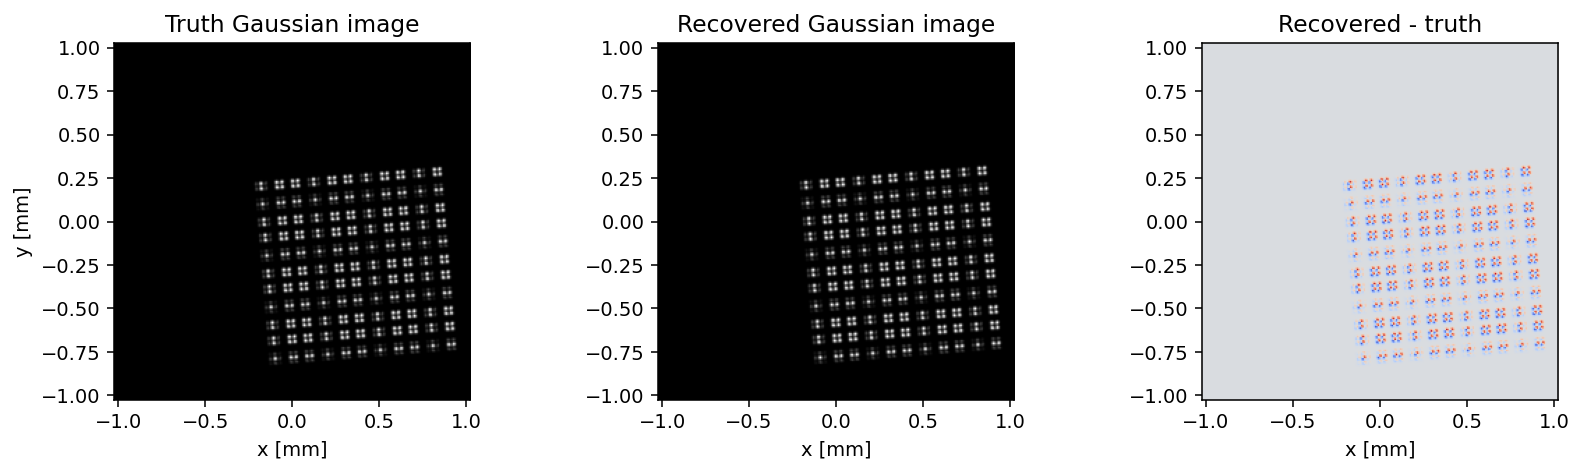

In [12]:
heldout_scale = 1.02
heldout_shift = np.array([-6e-6, 7e-6])
heldout_tilt = np.array([0.4e-3, -0.6e-3])

truth_image = render_output_image(p_truth, current_scale=heldout_scale, object_shift=heldout_shift, beam_tilt=heldout_tilt)
fit_image = render_output_image(p_fit, current_scale=heldout_scale, object_shift=heldout_shift, beam_tilt=heldout_tilt)
residual_image = fit_image - truth_image
rel_rms = np.sqrt(np.mean(residual_image**2)) / np.sqrt(np.mean(truth_image**2))
print(f"held-out Gaussian-image relative RMS residual: {rel_rms:.3e}")

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))
axs[0].imshow(truth_image, cmap="gray", extent=roi_extent_mm)
axs[0].set_title("Truth Gaussian image")
axs[1].imshow(fit_image, cmap="gray", extent=roi_extent_mm)
axs[1].set_title("Recovered Gaussian image")
axs[2].imshow(residual_image, cmap="coolwarm", extent=roi_extent_mm)
axs[2].set_title("Recovered - truth")
for ax in axs:
    ax.set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
plt.tight_layout()
show_figure(fig)


## Conclusion

Using only Gaussian-beam image data, the single-lens inversion is viable in this controlled synthetic case, but the demonstrated recovery is a first-order optics recovery from image measurements rather than a full coherent-image fit. The object is now a periodic waffle grating rather than a sparse square fiducial.

The important points are:

- The forward images are generated through TemGym's `ElectromagneticLens`, `Detector`, `run_to_end`, and Gaussian evaluation path.
- The object is supplied by `WaffleGrating`, with tunable `period`, `hole_width`, `hole_height`, support size, and transmission levels.
- The geometry is a real intermediate-image geometry for a `20 mm` lens with `M = -12`: `d1 ~= 20.70 mm`, `d2 ~= 275.58 mm`, and the image forms on a physical screen plane.
- The screen is represented as a `160 mm` green screen, while the Gaussian intensity is evaluated on a high-resolution detector ROI around the image.
- Centroids extracted from Gaussian output images are used to recover the transfer response and fit the lens parameters.
- Beam tilt is essential because it measures the `B` block. Current wobble is essential because it separates focal power, magnetic rotation, and effective thickness.
- The optical experiment recovers `NI`, `Gc_geom`, `Tc`, stigmator split, and lens centre. It still cannot split turns from current without external current/turn calibration.
- The held-out pixel residual remains a limitation because the fit uses centroid/pose information from coherent Gaussian images, not full intensity-pattern registration.

After changing the grating period or hole size, rerun the cleared cells from the object definition onward to refresh the figures and numerical fit.
